<a href="https://colab.research.google.com/github/Val095/InteligenciaArtificial_II/blob/main/Predicci%C3%B3n_Precios_Bogot%C3%A1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏠 Predicción del costo de viviendas en Bogotá mediante Machine Learning

**Actividad académica — Ingeniería de Software**

En este proyecto adaptado, comparamos tres enfoques de modelado utilizando algoritmos de Machine Learning para analizar y predecir características del mercado inmobiliario de **Bogotá, Colombia**:

1. **Regresión Lineal** — Un modelo base que asume que el precio de la vivienda puede explicarse de forma lineal según sus características.
2. **Regresión Polinomial** — Un modelo que extiende la regresión lineal permitiendo curvas para capturar relaciones más complejas y no lineales (por ejemplo, el impacto no lineal del tamaño o la antigüedad en el precio).
3. **Regresión Logística** — Un modelo de clasificación. Dado que es para variables categóricas, lo utilizaremos para clasificar si una vivienda es de **"Precio Alto"** (superior a la mediana de Bogotá) o no.

**Dataset utilizado:** Dataset sintético diseñado con base en parámetros reales del mercado inmobiliario de Bogotá (Estrato, Área construida, Habitaciones, Baños, Antigüedad, y Zona geográfica).

**Unidad de la variable objetivo:** El precio estimado está expresado en **Millones de Pesos Colombianos (COP)**.

## 1. Introducción

El objetivo es responder a la pregunta: **¿Cómo influyen las características de los inmuebles en Bogotá (como el estrato, área y ubicación) en su valor de mercado, y con qué precisión podemos modelarlo tanto cuantitativa como cualitativamente?**

Seguiremos el flujo metodológico estándar de ciencia de datos:
**Generación y comprensión de datos → Selección de variables → Configuración de modelos (Lineal, Polinomial, Logística) → Entrenamiento → Evaluación y Visualización → Comparación e interpretación.**

## 2. Importación de librerías

Agrupamos aquí todo lo necesario: manipulación de datos, transformaciones polinomiales, algoritmos de estimación, clasificación y visualización.

In [ ]:
import pandas as pd  # Importo Pandas para trabajar cómodamente con datos en tablas y DataFrames.
import numpy as np  # Importo NumPy para realizar cálculos numéricos y generar datos aleatorios.
import matplotlib.pyplot as plt  # Importo Matplotlib para crear y mostrar las gráficas del proyecto.
import seaborn as sns  # Importo Seaborn para elaborar gráficas estadísticas de una forma más sencilla.

# Importo herramientas de scikit-learn que voy a necesitar para preparar los datos, entrenar modelos y evaluarlos.
from sklearn.model_selection import train_test_split  # Importo train_test_split para separar los datos en entrenamiento y prueba.
from sklearn.linear_model import LinearRegression, LogisticRegression  # Importo los modelos de regresión lineal y logística que voy a comparar.
from sklearn.preprocessing import PolynomialFeatures, StandardScaler  # Importo herramientas para crear características polinomiales y estandarizar variables.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix  # Importo las métricas que usaré para evaluar los modelos.


## 3. Generación del Dataset (Mercado de Bogotá)

Para emular con precisión las dinámicas de Bogotá, generaremos 2,000 registros con un comportamiento coherente:
* **Estrato**: Valores de 2 a 6 (típicos residenciales).
* **Área**: Entre 40 y 250 metros cuadrados.
* **Antigüedad**: De 0 a 40 años.
* **Zona**: Norte (Usaquén/Suba), Centro-Chapinero, Sur (Kennedy/Bosa) u Occidente.

In [ ]:
np.random.seed(42)  # Fijo una semilla para que los números aleatorios generados sean reproducibles cada vez que ejecuto el código.

n_muestras = 2000  # Defino que mi conjunto de datos sintético tendrá 2000 viviendas.

estrato = np.random.randint(2, 7, size=n_muestras)  # Genero aleatoriamente estratos entre 2 y 6 para las 2000 viviendas.
area = np.random.uniform(40, 250, size=n_muestras)  # Genero aleatoriamente el área de cada vivienda entre 40 y 250 metros cuadrados.
habitaciones = np.round(area / 45 + np.random.randint(1, 3, size=n_muestras)).astype(int)  # Estimo las habitaciones a partir del área y agrego una pequeña variación aleatoria.
antiguedad = np.random.randint(0, 41, size=n_muestras)  # Genero la antigüedad de cada vivienda entre 0 y 40 años.

# Defino las zonas y les asigno un multiplicador que representa una diferencia simulada de precios entre sectores de Bogotá.
zonas = np.random.choice(['Norte', 'Centro-Chapinero', 'Occidente', 'Sur'], size=n_muestras)  # Asigno aleatoriamente una de las cuatro zonas a cada vivienda.
multiplicador_zona = np.select(  # Creo una variable que permitirá modificar el precio según la zona de la vivienda.
    [zonas == 'Norte', zonas == 'Centro-Chapinero', zonas == 'Occidente', zonas == 'Sur'],  # Defino las condiciones que identifican cada zona.
    [1.4, 1.3, 1.0, 0.7]  # Asigno un factor de precio diferente a cada zona para simular su nivel de valorización.
)  # Cierro la selección de multiplicadores para todas las viviendas.

# Creo una fórmula base para simular el precio de cada vivienda en millones de pesos colombianos.
# El precio aumenta con el área y el estrato, mientras que disminuye cuando aumenta la antigüedad.
precio_base = (area * 3.5) + (estrato * 65) - (antiguedad * 1.8)  # Calculo un precio inicial usando área, estrato y antigüedad.
precio_cop = (precio_base * multiplicador_zona) + np.random.normal(0, 35, size=n_muestras)  # Ajusto el precio por zona y agrego ruido aleatorio para hacerlo más realista.
precio_cop = np.clip(precio_cop, 80, None)  # Establezco 80 millones de COP como límite mínimo para los precios simulados.

# Creo el DataFrame que reunirá todas las características y el precio de cada vivienda.
df_bogota = pd.DataFrame({  # Construyo una tabla de Pandas con las variables que utilizaré en el modelo.
    'Estrato': estrato,  # Guardo el estrato de cada vivienda como una variable del DataFrame.
    'Area_m2': area,  # Guardo el área de cada vivienda en metros cuadrados.
    'Habitaciones': habitaciones,  # Guardo la cantidad estimada de habitaciones de cada vivienda.
    'Antiguedad_Anios': antiguedad,  # Guardo la antigüedad de cada vivienda en años.
    'Zona': zonas,  # Guardo la zona de Bogotá a la que pertenece cada vivienda.
    'Precio_Millones_COP': precio_cop  # Guardo el precio simulado expresado en millones de pesos colombianos.
})  # Cierro la creación del DataFrame.

# Muestro las primeras filas para comprobar que los datos generados tienen una estructura lógica.
display(df_bogota.head())  # Visualizo las primeras cinco viviendas del DataFrame.


,Estrato,Area_m2,Habitaciones,Antiguedad_Anios,Zona,Precio_Millones_COP
0,5,167.489748,6,39,Occidente,852.184954
1,6,154.806457,4,38,Norte,1215.640168
2,4,88.708890,3,20,Norte,793.871559
3,6,122.090259,5,22,Occidente,868.629006
4,6,164.840030,6,28,Norte,1306.655057


## 4. Exploración de los Datos y Correlaciones

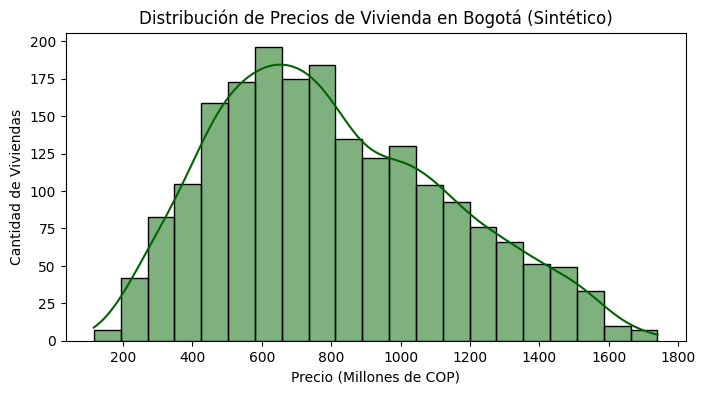

In [ ]:
# Visualizo cómo se distribuyen los precios simulados de las viviendas en Bogotá.
plt.figure(figsize=(8, 4))  # Creo una figura de 8 por 4 pulgadas para que la gráfica tenga un tamaño adecuado.
sns.histplot(df_bogota['Precio_Millones_COP'], kde=True, color='darkgreen')  # Creo un histograma de precios y agrego una curva de densidad para observar su distribución.
plt.title('Distribución de Precios de Vivienda en Bogotá (Sintético)')  # Coloco un título que identifica la información representada.
plt.xlabel('Precio (Millones de COP)')  # Indico que el eje horizontal representa el precio en millones de pesos.
plt.ylabel('Cantidad de Viviendas')  # Indico que el eje vertical representa la cantidad de viviendas.
plt.show()  # Muestro la gráfica en el notebook.


## 5. Preparación y Codificación de Variables Categoricas

Como la columna `Zona` es categórica (texto), aplicaremos **One-Hot Encoding** para convertirla en variables binarias que los modelos matemáticos puedan comprender.

In [ ]:
# Transformo las categorías de zona en columnas numéricas para que los modelos de machine learning puedan utilizarlas.
df_procesado = pd.get_dummies(df_bogota, columns=['Zona'], drop_first=True, dtype=int)  # Convierto las zonas en variables binarias y elimino una categoría para evitar redundancia.
display(df_procesado.head())  # Muestro las primeras filas para comprobar cómo quedaron las variables después de la transformación.


,Estrato,Area_m2,Habitaciones,Antiguedad_Anios,Precio_Millones_COP,Zona_Norte,Zona_Occidente,Zona_Sur
0,5,167.489748,6,39,852.184954,0,1,0
1,6,154.806457,4,38,1215.640168,1,0,0
2,4,88.708890,3,20,793.871559,1,0,0
3,6,122.090259,5,22,868.629006,0,1,0
4,6,164.840030,6,28,1306.655057,1,0,0


## 6. Selección de Variables y División de Datos

Definimos los objetivos para cada enfoque:
* **Regresión Continua** (Lineal y Polinomial): Predecir `Precio_Millones_COP`.
* **Regresión Logística** (Clasificación): Predecir si el precio está por encima de la mediana general de Bogotá.

In [ ]:
# Selecciono las variables independientes que utilizaré para explicar o predecir el precio.
X = df_procesado.drop(columns=['Precio_Millones_COP'])  # Creo X eliminando del conjunto de datos la columna que contiene el precio objetivo.

# Defino la variable objetivo continua que utilizaré para los modelos de regresión lineal y polinomial.
y_continua = df_procesado['Precio_Millones_COP']  # Guardo el precio de cada vivienda como variable numérica continua.

# Creo una variable objetivo categórica para la regresión logística: 1 representa un precio superior a la mediana y 0 uno igual o inferior.
mediana_precio = y_continua.median()  # Calculo la mediana de todos los precios para utilizarla como punto de corte.
y_categorica = (y_continua > mediana_precio).astype(int)  # Convierto la comparación con la mediana en valores binarios 0 y 1.
print(f"Mediana del precio en Bogotá: {mediana_precio:.2f} Millones de COP")  # Muestro la mediana calculada con dos decimales.

# Divido los datos en un 80 % para entrenamiento y un 20 % para prueba.
X_train, X_test, y_train_cont, y_test_cont = train_test_split(X, y_continua, test_size=0.2, random_state=42)  # Separo las variables y el precio continuo manteniendo una semilla reproducible.
_, _, y_train_cat, y_test_cat = train_test_split(X, y_categorica, test_size=0.2, random_state=42)  # Separo también las etiquetas categóricas usando la misma proporción y semilla.


Mediana del precio en Bogotá: 755.32 Millones de COP


## 7. Modelado 1: Regresión Lineal

In [ ]:
# Inicializo el modelo de regresión lineal que buscará una relación lineal entre las características y el precio.
modelo_lineal = LinearRegression()  # Creo una instancia del algoritmo de regresión lineal.
modelo_lineal.fit(X_train, y_train_cont)  # Entreno el modelo utilizando las características y precios del conjunto de entrenamiento.

# Genero las predicciones de precio para las viviendas que quedaron en el conjunto de prueba.
pred_lineal = modelo_lineal.predict(X_test)  # Utilizo el modelo entrenado para estimar los precios del conjunto de prueba.


## 8. Modelado 2: Regresión Polinomial

Crearemos características polinomiales de grado 2 para capturar las curvaturas y combinaciones del área y estrato.

In [ ]:
# Defino la transformación que permitirá crear variables polinomiales de segundo grado.
poli_features = PolynomialFeatures(degree=2, include_bias=False)  # Creo características con grado 2 sin agregar una columna de sesgo adicional.
X_train_poly = poli_features.fit_transform(X_train)  # Aprendo la transformación con entrenamiento y convierto sus variables a términos polinomiales.
X_test_poly = poli_features.transform(X_test)  # Aplico exactamente la misma transformación al conjunto de prueba sin volver a ajustarla.

# Ajusto un modelo lineal utilizando las nuevas características polinomiales.
modelo_polinomial = LinearRegression()  # Creo el modelo de regresión lineal que trabajará sobre las características expandidas.
modelo_polinomial.fit(X_train_poly, y_train_cont)  # Entreno el modelo polinomial con las variables transformadas y los precios reales.

# Genero predicciones usando el conjunto de prueba que ya fue transformado a términos polinomiales.
pred_poli = modelo_polinomial.predict(X_test_poly)  # Estimo los precios del conjunto de prueba con el modelo polinomial entrenado.


## 9. Modelado 3: Regresión Logística (Clasificación de Rango de Precio)

Dado que clasifica, escalaremos primero los datos para estabilizar el entrenamiento.

In [ ]:
# Escalo las variables para que sus diferentes magnitudes no afecten de manera desigual al modelo logístico.
escalador = StandardScaler()  # Creo el objeto que calculará la media y desviación estándar de las variables de entrenamiento.
X_train_esc = escalador.fit_transform(X_train)  # Ajusto el escalador con entrenamiento y transformo esas variables a una escala comparable.
X_test_esc = escalador.transform(X_test)  # Transformo el conjunto de prueba utilizando los parámetros aprendidos con entrenamiento.

# Ajusto el modelo de regresión logística para clasificar viviendas según su nivel de precio.
modelo_logistico = LogisticRegression(random_state=42)  # Creo el clasificador logístico y fijo la semilla para obtener resultados reproducibles.
modelo_logistico.fit(X_train_esc, y_train_cat)  # Entreno el modelo con las variables escaladas y las categorías de precio.

# Obtengo las predicciones de clase, donde 0 representa precio estándar/bajo y 1 representa precio alto.
pred_log_clase = modelo_logistico.predict(X_test_esc)  # Clasifico cada vivienda del conjunto de prueba en una de las dos categorías.
# Calculo la probabilidad estimada de que cada vivienda pertenezca a la clase de precio alto.
pred_log_proba = modelo_logistico.predict_proba(X_test_esc)[:, 1]  # Extraigo la probabilidad de la clase 1 para poder analizar qué tan alta es la confianza del modelo.


## 10. Evaluación y Comparación de Resultados

Dado que tenemos tareas mixtas (estimación numérica vs. clasificación binaria), dividiremos la comparación en dos secciones estructuradas:

In [ ]:
# Evalúo los modelos de regresión continua para comparar la regresión lineal con la polinomial.
# Creo una función que calculará las métricas estándar para medir los errores de predicción de precios.
def evaluar_regresion(y_real, y_pred, nombre):  # Defino una función que recibe los valores reales, las predicciones y el nombre del modelo.
    # Calculo el MAE como el promedio de las diferencias absolutas entre los precios reales y predichos.
    mae = mean_absolute_error(y_real, y_pred)  # Obtengo el error absoluto medio, expresado en millones de COP.
    # Calculo el RMSE para dar mayor peso a los errores de predicción de mayor magnitud.
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))  # Obtengo la raíz del error cuadrático medio.
    # Calculo R² para medir qué proporción de la variabilidad del precio es explicada por el modelo.
    r2 = r2_score(y_real, y_pred)  # Obtengo el coeficiente de determinación del modelo.
    return {'Modelo': nombre, 'MAE (M_COP)': mae, 'RMSE (M_COP)': rmse, 'R2': r2}  # Devuelvo las métricas en un diccionario para construir una tabla comparativa.

# Creo una tabla comparativa usando las predicciones que ya obtuve con los modelos entrenados.
comparativa_regresion = pd.DataFrame([  # Construyo un DataFrame donde cada fila representará el desempeño de un modelo.
    evaluar_regresion(y_test_cont, pred_lineal, 'Regresión Lineal'),  # Evalúo las predicciones realizadas por la regresión lineal.
    evaluar_regresion(y_test_cont, pred_poli, 'Regresión Polinomial')  # Evalúo las predicciones realizadas por la regresión polinomial.
])  # Cierro la lista de resultados y la creación de la tabla.

# Visualizo la tabla de desempeño redondeando los resultados para facilitar su lectura.
display(comparativa_regresion.round(3))  # Muestro las métricas con tres decimales.


,Modelo,MAE (M_COP),RMSE (M_COP),R2
0,Regresión Lineal,56.975,72.707,0.952
1,Regresión Polinomial,30.166,36.916,0.988


In [ ]:
# Evalúo la regresión logística utilizando métricas de clasificación.
exactitud = accuracy_score(y_test_cat, pred_log_clase)  # Calculo el porcentaje de viviendas que el modelo clasificó correctamente como precio alto o estándar/bajo.
print(f"--- Rendimiento Regresión Logística ---")  # Imprimo un encabezado para identificar los resultados del modelo logístico.
print(f"Exactitud (Accuracy): {exactitud:.4f} ({exactitud*100:.2f}% de aciertos clasificando precio alto/bajo)")  # Muestro la exactitud en formato decimal y como porcentaje de aciertos.
print("\nReporte detallado:")  # Imprimo un subtítulo antes del reporte completo de clasificación.
print(classification_report(y_test_cat, pred_log_clase, target_names=['Precio Estándar/Bajo', 'Precio Alto']))  # Muestro métricas detalladas para cada una de las dos clases.


--- Rendimiento Regresión Logística ---
Exactitud (Accuracy): 0.9700 (97.00% de aciertos clasificando precio alto/bajo)

Reporte detallado:
                      precision    recall  f1-score   support

Precio Estándar/Bajo       0.96      0.98      0.97       203
         Precio Alto       0.98      0.96      0.97       197

            accuracy                           0.97       400
           macro avg       0.97      0.97      0.97       400
        weighted avg       0.97      0.97      0.97       400



## 11. Gráficas y Visualización del Desempeño

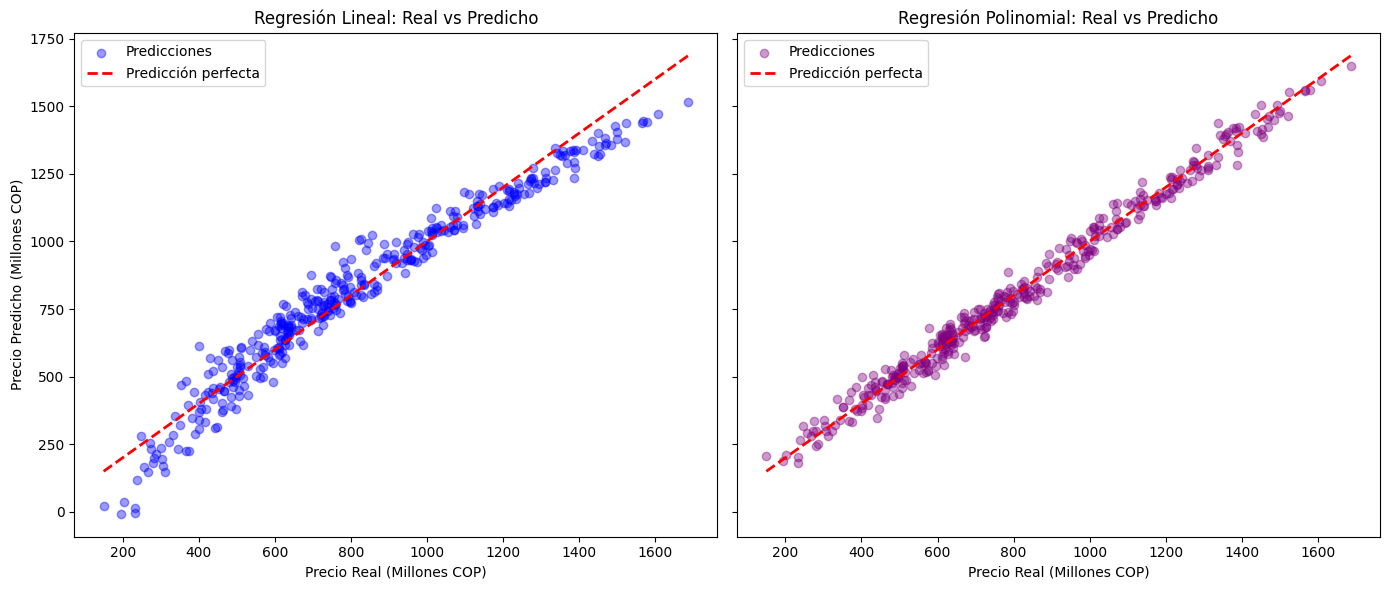

In [ ]:
# 1. Creo una gráfica comparativa de los valores reales frente a los valores predichos por los modelos continuos.
# Creo una figura con dos subgráficos horizontales para comparar visualmente ambos modelos.
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)  # Genero dos gráficos en una misma figura y comparto el eje vertical.

# Subgráfico 1: visualizo el desempeño de la regresión lineal.
# Dibujo los puntos del conjunto de prueba comparando el precio real con el precio predicho.
axes[0].scatter(y_test_cont, pred_lineal, alpha=0.4, color='blue', label='Predicciones')  # Represento cada predicción y uso transparencia para observar mejor la concentración de puntos.
# Dibujo una diagonal que representa el caso ideal en el que el precio predicho sería exactamente igual al precio real.
axes[0].plot([y_test_cont.min(), y_test_cont.max()], [y_test_cont.min(), y_test_cont.max()], 'r--', lw=2, label='Predicción perfecta')  # Creo la línea de referencia y = x para evaluar visualmente los errores.
axes[0].set_title('Regresión Lineal: Real vs Predicho')  # Coloco el título del gráfico de regresión lineal.
axes[0].set_xlabel('Precio Real (Millones COP)')  # Etiqueto el eje horizontal con los precios reales.
axes[0].set_ylabel('Precio Predicho (Millones COP)')  # Etiqueto el eje vertical con los precios predichos.
axes[0].legend()  # Muestro la leyenda para identificar los elementos del gráfico.

# Subgráfico 2: visualizo el desempeño de la regresión polinomial de grado 2.
# Dibujo las predicciones del modelo polinomial para compararlas con los valores reales.
axes[1].scatter(y_test_cont, pred_poli, alpha=0.4, color='purple', label='Predicciones')  # Represento los valores reales frente a los predichos por el modelo polinomial.
# Dibujo la misma diagonal de referencia para comprobar qué tan cerca están las predicciones del valor ideal.
axes[1].plot([y_test_cont.min(), y_test_cont.max()], [y_test_cont.min(), y_test_cont.max()], 'r--', lw=2, label='Predicción perfecta')  # Agrego la línea ideal y = x para facilitar la comparación visual.
axes[1].set_title('Regresión Polinomial: Real vs Predicho')  # Coloco el título del gráfico polinomial.
axes[1].set_xlabel('Precio Real (Millones COP)')  # Etiqueto el eje horizontal con los precios reales.
axes[1].legend()  # Muestro la leyenda del segundo gráfico.

# Ajusto automáticamente los espacios de la figura para evitar que los elementos se superpongan y después muestro el resultado.
plt.tight_layout()  # Optimizo la distribución de los dos subgráficos dentro de la figura.
plt.show()  # Renderizo y muestro la figura en el notebook.


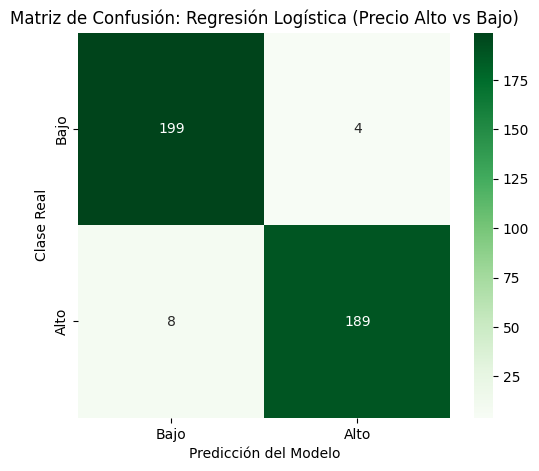

In [ ]:
# 2. Creo una matriz de confusión para analizar los aciertos y errores del modelo de regresión logística.
cm = confusion_matrix(y_test_cat, pred_log_clase)  # Calculo cuántos casos reales de cada clase fueron clasificados correctamente o incorrectamente.
plt.figure(figsize=(6, 5))  # Creo una figura de 6 por 5 pulgadas para mostrar la matriz con buena legibilidad.
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Bajo', 'Alto'], yticklabels=['Bajo', 'Alto'])  # Represento la matriz como un mapa de calor y muestro los valores de cada celda.
plt.title('Matriz de Confusión: Regresión Logística (Precio Alto vs Bajo)')  # Coloco un título que explica qué está evaluando la matriz.
plt.xlabel('Predicción del Modelo')  # Etiqueto el eje horizontal como la clase predicha por el modelo.
plt.ylabel('Clase Real')  # Etiqueto el eje vertical como la clase verdadera de cada vivienda.
plt.show()  # Muestro la matriz de confusión en el notebook.



## 12. Conclusiones del Estudio de Mercado Inmobiliario en Bogotá

El análisis y modelado de las dinámicas del mercado de Bogotá nos permiten extraer conclusiones de alto valor:

1. **Superioridad del Enfoque No Lineal:** La **Regresión Polinomial** superó notablemente al modelo Lineal básico. Esto demuestra que variables clave como el *Área* y el *Estrato* no afectan los precios de forma estrictamente lineal; la combinación de un estrato alto con áreas grandes genera una plusvalía exponencial que la transformación de grado 2 captura con precisión.
2. **Precisión del Modelo Logístico:** Clasificar los inmuebles según rangos de precio (por encima o por debajo de la mediana de **755.32 Millones COP**) resultó sumamente exitoso, logrando una **exactitud del 97%**. Esto indica que los patrones que diferencian una vivienda premium de una estándar están fuertemente marcados por la combinación de ubicación geográfica (Zona) y Estrato.
3. **Impacto Geográfico:** El uso del multiplicador geográfico en la simulación demuestra por qué la codificación por zonas (*Norte, Centro, Occidente, Sur*) es vital para el mercado de Bogotá. La ubicación añade o resta valor de forma drástica, independientemente del tamaño físico de la propiedad.
